# Voice Command Fingerprinting Attack - Modern Implementation

This notebook provides a modernized, exact implementation of the VCFingerprinting attack from:

**"I Can Hear Your Alexa: Voice Command Fingerprinting on Smart Home Speakers"**  
IEEE Conference on Communications and Network Security (IEEE CNS 2019)

Authors: Sean Kennedy, Haipeng Li, Chenggang Wang, Hao Liu, Boyang Wang, Wenhai Sun

---

## Attack Methods (Per Paper Table I)

| Method | Description | Paper Accuracy |
|--------|-------------|----------------|
| **LL-Jaccard** | Jaccard similarity on packet sets | 17.4% |
| **LL-NB** | Naive Bayes with packet size histogram | 33.8% |
| **VNG++** | Naive Bayes with burst features | 24.9% |
| **P-SVM (AdaBoost)** | AdaBoost with SVM features | 33.4% |
| **Random Guess** | 1/M baseline (M=100 classes) | 1% |

## Evaluation Metrics
- **Accuracy**: Correct classification rate
- **Semantic Distance**: Cosine similarity using doc2vec
- **Normalized Semantic Distance**: Rank-based distance metric

## 1. Setup and Imports

In [1]:
# Core libraries
import os
import re
import logging
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Set, Optional, Any, Union
from collections import defaultdict
from dataclasses import dataclass
import math

# Data processing
import numpy as np
import pandas as pd

# Machine learning
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# NLP for semantic distance
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Plot settings (matching paper style)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# Constants
LABELSIZE = 18
LEGENDSIZE = 18
TICKSIZE = 16

print("✅ All libraries imported successfully!")
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
📦 NumPy version: 2.4.2
📦 Pandas version: 3.0.1


## 2. Configuration and Data Paths

In [46]:
@dataclass
class Config:
    """Configuration for the VCFingerprinting implementation."""
    # Data paths
    base_dir: Path = Path('../data/original')
    data_dir: Path = None  # Will be set in __post_init__
    trace_csv_dir: Path = None
    query_list_file: Path = None
    output_dir: Path = None
    
    # Feature parameters (per paper)
    bayes_range: Tuple[int, int, int] = (-1500, 1501, 100)  # start, end, interval
    vngpp_range: Tuple[int, int, int] = (-400000, 400001, 5000)
    svm_range: Tuple[int, int, int] = (-200000, 200001, 5000)
    
    # Cross-validation
    n_folds: int = 5
    random_state: int = 42
    
    def __post_init__(self):
        self.data_dir = self.base_dir / 'data'
        self.trace_csv_dir = self.data_dir / 'trace_csv'
        self.query_list_file = self.data_dir / 'amazon_echo_query_list_100.xlsx'
        self.output_dir = self.base_dir / 'figures'
        self.output_dir.mkdir(parents=True, exist_ok=True)

config = Config()
print(f"📁 Data directory: {config.data_dir}")
print(f"📁 Trace CSV directory: {config.trace_csv_dir}")
print(f"📁 Output directory: {config.output_dir}")

📁 Data directory: ../data/original/data
📁 Trace CSV directory: ../data/original/data/trace_csv
📁 Output directory: ../data/original/figures


## 3. Utility Functions (Recreated from Original)

The original code used `tools.py` and `fileUtils.py` modules that are recreated here with modern Python.

In [3]:
class FeatureUtils:
    """Utility functions for feature extraction (recreated from original tools.py)."""
    
    @staticmethod
    def get_section_list(start: int, end: int, interval: int) -> Tuple[List[int], List[int]]:
        """
        Create bins for histogram-like feature extraction.
        
        Args:
            start: Start of range
            end: End of range (exclusive)
            interval: Bin size
        
        Returns:
            Tuple of (range_list, zero_initialized_sections)
        """
        range_list = list(range(start, end, interval))
        section_list = [0] * len(range_list)
        return range_list, section_list
    
    @staticmethod
    def compute_range(range_list: List[int], value: int) -> int:
        """
        Find the bin index for a given value.
        
        Args:
            range_list: List of bin boundaries
            value: Value to bin
        
        Returns:
            Bin index
        """
        for i, threshold in enumerate(range_list):
            if value < threshold:
                return i
        return len(range_list) - 1


class FileUtils:
    """File handling utilities (recreated from original fileUtils.py)."""
    
    @staticmethod
    def str2int(str_input: Union[str, float, int]) -> int:
        """Convert string/float to int, handling float strings."""
        if isinstance(str_input, (int, np.integer)):
            return int(str_input)
        if isinstance(str_input, float):
            return int(str_input)
        if '.' in str(str_input):
            return int(float(str_input))
        return int(str_input)
    
    @staticmethod
    def str2float(str_input: Union[str, float, int]) -> float:
        """Convert string to float."""
        return float(str_input)


class LabelUtils:
    """Label extraction utilities."""
    
    @staticmethod
    def get_label(fpath: str) -> str:
        """
        Extract command label from filename.
        
        Pattern matches: ([a-zA-Z']*[a-zA-Z_]+)_[0-9].*
        Examples:
            'alexa_5_30s_L_1.csv' -> 'alexa'
            'do_dogs_dream_5_1.csv' -> 'do dogs dream'
        """
        pattern = r"([a-zA-Z']*[a-zA-Z_]+)_[0-9]"
        fname = os.path.basename(fpath)
        m = re.match(pattern, fname)
        if m:
            return m.group(1).replace('_', ' ')
        return fname

print("✅ Utility classes defined!")

✅ Utility classes defined!


## 4. Data Loading and Exploration

In [4]:
def load_trace_files(data_dir: Path) -> List[Path]:
    """Load all CSV trace files from directory."""
    csv_files = sorted(data_dir.glob('*.csv'))
    logger.info(f"Found {len(csv_files)} CSV trace files")
    return csv_files

def load_query_list(query_file: Path) -> pd.DataFrame:
    """Load the query list Excel file."""
    df = pd.read_excel(query_file)
    logger.info(f"Loaded query list with {len(df)} queries")
    return df

def load_single_trace(fpath: Path) -> pd.DataFrame:
    """Load a single trace CSV file."""
    df = pd.read_csv(fpath)
    return df

# Load data
csv_files = load_trace_files(config.trace_csv_dir)
query_df = load_query_list(config.query_list_file)

print(f"\n📊 Total CSV files: {len(csv_files)}")
print(f"📊 Query list shape: {query_df.shape}")
print(f"\nFirst 5 queries:")
print(query_df.head())

2026-02-22 03:06:38,349 - INFO - Found 1000 CSV trace files
2026-02-22 03:06:38,419 - INFO - Loaded query list with 100 queries



📊 Total CSV files: 1000
📊 Query list shape: (100, 1)

First 5 queries:
                               Query 
0    What is the AFC North Standings?
1       What is the colts pats score?
2                        Flip a coin.
3                       Good Morning.
4  Translate good morning to Spanish.


In [5]:
# Examine a sample trace file
sample_trace = load_single_trace(csv_files[0])
print(f"📄 Sample file: {csv_files[0].name}")
print(f"📄 Shape: {sample_trace.shape}")
print(f"📄 Columns: {list(sample_trace.columns)}")
print(f"\nFirst 10 rows:")
print(sample_trace.head(10))

📄 Sample file: alexa_5_30s_L_1.csv
📄 Shape: (569, 4)
📄 Columns: ['Unnamed: 0', 'time', 'size', 'direction']

First 10 rows:
   Unnamed: 0      time    size  direction
0           0  0.000000   176.0        1.0
1           1  0.000570  1500.0        1.0
2           2  0.000602  1500.0        1.0
3           3  0.000625  1163.0        1.0
4           4  0.005253   118.0        1.0
5           5  0.006870   166.0        1.0
6           6  0.006898  1500.0        1.0
7           7  0.015756    40.0       -1.0
8           8  0.016546    40.0       -1.0
9           9  0.017853   146.0        1.0


In [6]:
# Extract labels and create mappings
file_labels = {str(fpath): LabelUtils.get_label(str(fpath)) for fpath in csv_files}
unique_labels = sorted(set(file_labels.values()))

label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(f"📊 Number of unique voice commands (classes): {len(unique_labels)}")
print(f"\nSample labels (first 20):")
for i, label in enumerate(unique_labels[:20]):
    print(f"  {label_to_idx[label]:3d}: {label}")

# Count samples per class
label_counts = defaultdict(int)
for label in file_labels.values():
    label_counts[label] += 1

print(f"\n📊 Samples per class (first 10):")
for label in sorted(label_counts.keys())[:10]:
    print(f"  {label}: {label_counts[label]}")

📊 Number of unique voice commands (classes): 100

Sample labels (first 20):
    0: alexa
    1: do dogs dream
    2: do you like cats or dogs
    3: flip a coin
    4: give me a dinosaur fact
    5: good morning
    6: help
    7: how deep is the indian ocean
    8: how do you spell appreciate
    9: how far away is the moon
   10: how hot is the sun
   11: how many days are in september
   12: how many days in a year
   13: how many days until christmas
   14: how many days until thanksgiving
   15: how many fantasy points does lebron james have
   16: how many ounces in a pound
   17: how many seconds in a year
   18: how many teaspoons in a table spoon
   19: how much is an ounce of gold

📊 Samples per class (first 10):
  alexa: 10
  do dogs dream: 10
  do you like cats or dogs: 10
  flip a coin: 10
  give me a dinosaur fact: 10
  good morning: 10
  help: 10
  how deep is the indian ocean: 10
  how do you spell appreciate: 10
  how far away is the moon: 10


## 5. Feature Extraction Functions

### 5.1 Trace File Reader

In [7]:
def read_trace_file(fpath: Path) -> Tuple[int, int, int, int, List[float], List[Tuple[int, int]]]:
    """
    Read a trace CSV file and extract packet information.
    
    Args:
        fpath: Path to trace CSV file
    
    Returns:
        Tuple: (upPackNum, downPackNum, upStreamTotal, downStreamTotal, 
                traceTimeList, packetTuples)
    """
    up_pack_num = 0
    down_pack_num = 0
    up_stream_total = 0
    down_stream_total = 0
    trace_time_list = []
    packet_tuples = []  # (size, direction) tuples
    
    df = pd.read_csv(fpath)
    
    for _, row in df.iterrows():
        size = FileUtils.str2int(row['size'])
        direction = FileUtils.str2int(row['direction'])
        time = FileUtils.str2float(row['time'])
        
        trace_time_list.append(time)
        packet_tuples.append((size, direction))
        
        if direction == 1:  # Speaker is source (upstream)
            up_stream_total += size
            up_pack_num += 1
        elif direction == -1:  # Speaker is destination (downstream)
            down_stream_total += size
            down_pack_num += 1
    
    return (up_pack_num, down_pack_num, up_stream_total, down_stream_total,
            trace_time_list, packet_tuples)


def calculate_bursts(packet_tuples: List[Tuple[int, int]]) -> List[int]:
    """
    Calculate traffic bursts (consecutive packets in same direction).
    
    From paper: A burst is defined as a sequence of consecutive packets
    going a same direction.
    
    Args:
        packet_tuples: List of (size, direction) tuples
    
    Returns:
        List of burst sizes (size * direction for signed values)
    """
    if not packet_tuples:
        return []
    
    burst_list = []
    direction = packet_tuples[0][1]
    tmp_burst = packet_tuples[0][0] * packet_tuples[0][1]  # size * direction
    
    for i in range(1, len(packet_tuples)):
        item = packet_tuples[i]
        tmp_direc = item[1]
        
        if direction != tmp_direc:
            burst_list.append(tmp_burst)
            direction = tmp_direc
            tmp_burst = item[0] * item[1]
        else:
            tmp_burst += item[0] * item[1]
    
    burst_list.append(tmp_burst)
    return burst_list


# Test on sample file
sample_result = read_trace_file(csv_files[0])
print(f"📄 Sample trace: {csv_files[0].name}")
print(f"  Up packets: {sample_result[0]}, Down packets: {sample_result[1]}")
print(f"  Up bytes: {sample_result[2]}, Down bytes: {sample_result[3]}")
print(f"  Total packets: {len(sample_result[5])}")

sample_bursts = calculate_bursts(sample_result[5])
print(f"  Number of bursts: {len(sample_bursts)}")
print(f"  First 5 bursts: {sample_bursts[:5]}")

📄 Sample trace: alexa_5_30s_L_1.csv
  Up packets: 332, Down packets: 237
  Up bytes: 73057, Down bytes: 11129
  Total packets: 569
  Number of bursts: 323
  First 5 bursts: [6123, -80, 594, -40, 1500]


### 5.2 LL-NB (Bayes) Feature Extraction

From paper: LL-NB exploits a Naive Bayes classifier, where the features are packet sizes.
Packet sizes are rounded to the nearest multiple of the rounding parameter (default 100).

In [8]:
def compute_bayes_feature(fpath: Path, interval: int = 100) -> np.ndarray:
    """
    Compute packet size histogram features for LL-NB (Bayes) classifier.
    
    Creates a histogram of packet sizes (size * direction) with given bin size.
    Range: -1500 to 1500 bytes (per paper).
    
    Args:
        fpath: Path to trace CSV file
        interval: Bin size for histogram (default: 100, per paper)
    
    Returns:
        numpy.ndarray: Feature vector (histogram bins)
    """
    start, end = -1500, 1501
    range_list, section_list = FeatureUtils.get_section_list(start, end, interval)
    
    df = pd.read_csv(fpath)
    
    for _, row in df.iterrows():
        size = FileUtils.str2int(row['size'])
        direction = FileUtils.str2int(row['direction'])
        feat = size * direction
        index = FeatureUtils.compute_range(range_list, feat)
        section_list[index] += 1
    
    return np.array(section_list)

# Test
sample_bayes = compute_bayes_feature(csv_files[0], interval=100)
print(f"📊 Bayes feature vector shape: {sample_bayes.shape}")
print(f"📊 Feature vector (first 20): {sample_bayes[:20]}")
print(f"📊 Non-zero bins: {np.count_nonzero(sample_bayes)}")

📊 Bayes feature vector shape: (31,)
📊 Feature vector (first 20): [  0   0   0   0   0   0   0   0   0   0   0   1   1   0   6 229  23 285
   4   1]
📊 Non-zero bins: 13


### 5.3 VNG++ Feature Extraction

From paper: VNG++ leverages coarse information including total trace time,
upstream/downstream total bytes, and bytes in traffic bursts.

In [9]:
def compute_vngpp_feature(fpath: Path, interval: int = 5000) -> List[float]:
    """
    Compute VNG++ features including burst statistics.
    
    Features (per paper):
        1. Total trace time
        2. Upstream total bytes
        3. Downstream total bytes
        4. Burst histogram (range: -400000 to 400000)
    
    Args:
        fpath: Path to trace CSV file
        interval: Bin size for burst histogram (default: 5000, per paper)
    
    Returns:
        List: Feature vector
    """
    up_pack_num, down_pack_num, up_stream_total, down_stream_total, \
        trace_time_list, packet_tuples = read_trace_file(fpath)
    
    # Calculate bursts
    burst_list = calculate_bursts(packet_tuples)
    
    # Create burst histogram
    start, end = -400000, 400001
    range_list, section_list = FeatureUtils.get_section_list(start, end, interval)
    
    for feat in burst_list:
        index = FeatureUtils.compute_range(range_list, feat)
        section_list[index] += 1
    
    # Calculate total trace time
    trace_time_list.sort()
    total_trace_time = trace_time_list[-1] - trace_time_list[0] if len(trace_time_list) > 1 else 0
    
    # Combine features
    features = [total_trace_time, up_stream_total, down_stream_total]
    features.extend(section_list)
    
    return features

# Test
sample_vngpp = compute_vngpp_feature(csv_files[0], interval=5000)
print(f"📊 VNG++ feature vector length: {len(sample_vngpp)}")
print(f"📊 First 5 features (time, up, down, burst_hist[0:2]): {sample_vngpp[:5]}")

📊 VNG++ feature vector length: 164
📊 First 5 features (time, up, down, burst_hist[0:2]): [6.606452465057373, 73057, 11129, 0, 0]


### 5.4 P-SVM (AdaBoost) Feature Extraction

From paper: P-SVM considers features including bursts, total transmitted bytes,
number of bursts, occurring packet sizes, percentage incoming packets, and number of packets.
The paper uses AdaBoost as the classifier since SVM only achieved 1.2% accuracy.

In [10]:
def compute_svm_feature(fpath: Path, interval: int = 5000) -> List[float]:
    """
    Compute P-SVM features for AdaBoost classifier.
    
    Features (per paper):
        1. Upstream total bytes
        2. Downstream total bytes
        3. Percentage incoming packets
        4. Number of packets
        5. Number of bursts
        6. Burst histogram (range: -200000 to 200000)
    
    Args:
        fpath: Path to trace CSV file
        interval: Bin size for burst histogram (default: 5000)
    
    Returns:
        List: Feature vector
    """
    up_pack_num, down_pack_num, up_stream_total, down_stream_total, \
        trace_time_list, packet_tuples = read_trace_file(fpath)
    
    # Calculate bursts
    burst_list = calculate_bursts(packet_tuples)
    
    # Create burst histogram
    start, end = -200000, 200001
    range_list, section_list = FeatureUtils.get_section_list(start, end, interval)
    
    for feat in burst_list:
        index = FeatureUtils.compute_range(range_list, feat)
        section_list[index] += 1
    
    # Additional features
    total_packets = up_pack_num + down_pack_num
    in_pack_ratio = down_pack_num / total_packets if total_packets > 0 else 0
    pack_num = len(packet_tuples)
    burst_num = len(burst_list)
    
    # Combine features
    features = [up_stream_total, down_stream_total, in_pack_ratio, pack_num, burst_num]
    features.extend(section_list)
    
    return features

# Test
sample_svm = compute_svm_feature(csv_files[0], interval=5000)
print(f"📊 P-SVM feature vector length: {len(sample_svm)}")
print(f"📊 First 5 features (up, down, ratio, packs, bursts): {sample_svm[:5]}")

📊 P-SVM feature vector length: 86
📊 First 5 features (up, down, ratio, packs, bursts): [73057, 11129, 0.4165202108963093, 569, 323]


### 5.5 LL-Jaccard Feature Extraction

From paper: Each traffic trace is represented as a set, where each element is
a positive or negative integer corresponding to the packet length and direction.

In [11]:
def compute_jaccard_feature(fpath: Path) -> Set[int]:
    """
    Read raw packet sequence for LL-Jaccard similarity.
    
    Returns:
        Set of (size * direction) values
    """
    df = pd.read_csv(fpath)
    features = set()
    
    for _, row in df.iterrows():
        size = FileUtils.str2int(row['size'])
        direction = FileUtils.str2int(row['direction'])
        feat = size * direction
        features.add(feat)
    
    return features


def compute_jaccard_similarity(set_a: Set[int], set_b: Set[int]) -> float:
    """
    Compute Jaccard similarity between two sets.
    
    J(A,B) = |A ∩ B| / |A ∪ B|
    
    Args:
        set_a: First set
        set_b: Second set
    
    Returns:
        Jaccard similarity coefficient (0 to 1)
    """
    intersection = set_a.intersection(set_b)
    union = set_a.union(set_b)
    return len(intersection) / len(union) if len(union) > 0 else 0

# Test
sample_jaccard = compute_jaccard_feature(csv_files[0])
print(f"📊 Jaccard feature set size: {len(sample_jaccard)}")
print(f"📊 Sample features (first 10): {list(sample_jaccard)[:10]}")

# Test similarity
sample_jaccard2 = compute_jaccard_feature(csv_files[1])
similarity = compute_jaccard_similarity(sample_jaccard, sample_jaccard2)
print(f"\n📊 Jaccard similarity between first two traces: {similarity:.4f}")

📊 Jaccard feature set size: 36
📊 Sample features (first 10): [394, 1163, -113, 272, 273, 146, 158, 166, 40, 298]

📊 Jaccard similarity between first two traces: 0.5000


## 6. Dataset Loading

In [12]:
def load_dataset(data_dir: Path, method: str = 'Bayes', interval: int = 100) -> Tuple:
    """
    Load dataset with specified feature extraction method.
    
    Args:
        data_dir: Path to data directory
        method: 'Bayes', 'VNGpp', 'SVM', or 'Jaccard'
        interval: Binning interval
    
    Returns:
        Tuple: (features, labels, label_to_idx, idx_to_label, file_list)
    """
    csv_files = sorted(list(data_dir.glob('*.csv')))
    
    features_list = []
    labels_list = []
    file_list = []
    
    # Extract labels
    file_labels = {str(fpath): LabelUtils.get_label(str(fpath)) for fpath in csv_files}
    unique_labels = sorted(set(file_labels.values()))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    idx_to_label = {idx: label for label, idx in label_to_idx.items()}
    
    logger.info(f"Loading {len(csv_files)} files with method: {method}")
    
    for fpath in csv_files:
        try:
            if method == 'Bayes':
                feat = compute_bayes_feature(fpath, interval=interval)
                features_list.append(feat)
            elif method == 'VNGpp':
                feat = compute_vngpp_feature(fpath, interval=interval)
                features_list.append(feat)
            elif method == 'SVM':
                feat = compute_svm_feature(fpath, interval=interval)
                features_list.append(feat)
            elif method == 'Jaccard':
                feat = compute_jaccard_feature(fpath)
                features_list.append(feat)
            else:
                raise ValueError(f"Unknown method: {method}")
            
            file_list.append(str(fpath))
            labels_list.append(label_to_idx[file_labels[str(fpath)]])
            
        except Exception as e:
            logger.error(f"Error loading {fpath}: {e}")
    
    if method != 'Jaccard':
        X = np.array(features_list)
    else:
        X = features_list  # List of sets for Jaccard
    
    y = np.array(labels_list)
    
    logger.info(f"Loaded {len(X)} samples, {len(unique_labels)} classes")
    
    return X, y, label_to_idx, idx_to_label, file_list

# Test loading
X_bayes, y_bayes, label_map, idx_label_map, files = load_dataset(
    config.trace_csv_dir, method='Bayes', interval=100
)
print(f"\n📊 Bayes dataset shape: {X_bayes.shape}")
print(f"📊 Labels shape: {y_bayes.shape}")
print(f"📊 Number of classes: {len(label_map)}")

2026-02-22 03:06:38,531 - INFO - Loading 1000 files with method: Bayes
2026-02-22 03:06:44,611 - INFO - Loaded 1000 samples, 100 classes



📊 Bayes dataset shape: (1000, 31)
📊 Labels shape: (1000,)
📊 Number of classes: 100


## 7. Classification Algorithms

### 7.1 LL-NB (Naive Bayes) Classifier

In [13]:
def train_bayes(X_train: np.ndarray, y_train: np.ndarray) -> GaussianNB:
    """Train LL-NB (Gaussian Naive Bayes) classifier."""
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model

def predict_bayes(model: GaussianNB, X_test: np.ndarray) -> np.ndarray:
    """Predict using LL-NB classifier."""
    return model.predict(X_test)

print("✅ LL-NB (Bayes) classifier functions defined!")

✅ LL-NB (Bayes) classifier functions defined!


### 7.2 VNG++ Classifier

In [14]:
def train_vngpp(X_train: np.ndarray, y_train: np.ndarray) -> GaussianNB:
    """Train VNG++ classifier (Naive Bayes with burst features)."""
    model = GaussianNB()
    model.fit(X_train, y_train)
    return model

def predict_vngpp(model: GaussianNB, X_test: np.ndarray) -> np.ndarray:
    """Predict using VNG++ classifier."""
    return model.predict(X_test)

print("✅ VNG++ classifier functions defined!")

✅ VNG++ classifier functions defined!


### 7.3 P-SVM (AdaBoost) Classifier

From paper: "since the results based on the implementation with SVM only achieves 1.2% accuracy
and we could not find optimized parameters of SVM to improve the attack results, we implement
this attack with the same features but utilize AdaBoost as an alternative classifier."

In [15]:
def train_svm_adaboost(X_train: np.ndarray, y_train: np.ndarray, 
                       n_estimators: int = 50) -> AdaBoostClassifier:
    """
    Train P-SVM with AdaBoost classifier (per paper).
    
    Paper uses AdaBoost because SVM only achieved 1.2% accuracy.
    """
    from sklearn.tree import DecisionTreeClassifier
    
    # Use decision stumps (default for AdaBoost) as per standard practice
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators,
        random_state=config.random_state
    )
    model.fit(X_train, y_train)
    return model

def predict_svm_adaboost(model: AdaBoostClassifier, X_test: np.ndarray) -> np.ndarray:
    """Predict using P-SVM (AdaBoost) classifier."""
    return model.predict(X_test)

print("✅ P-SVM (AdaBoost) classifier functions defined!")

✅ P-SVM (AdaBoost) classifier functions defined!


### 7.4 LL-Jaccard Classifier

From paper: LL-Jaccard utilizes Jaccard similarity to classify unlabeled traffic traces.

In [16]:
def train_jaccard(X_train: List[Set[int]], y_train: np.ndarray, 
                  idx_to_label: Dict) -> Dict[str, Set[int]]:
    """
    Train LL-Jaccard by creating class prototype sets.
    
    Per paper Section III-A and original code: Creates a prototype set
    for each class by taking elements that appear in >50% of samples.
    
    Args:
        X_train: List of sets (one per sample)
        y_train: Labels
        idx_to_label: Label index to name mapping
    
    Returns:
        Dict mapping class names to prototype sets
    """
    # Group samples by class
    class_samples = defaultdict(list)
    for feat_set, label in zip(X_train, y_train):
        class_samples[label].append(feat_set)
    
    # Create prototype for each class using majority voting
    class_prototypes = {}
    
    for label_idx, sample_sets in class_samples.items():
        label_name = idx_to_label[label_idx]
        threshold = math.ceil(len(sample_sets) / 2)
        
        # Count element occurrences across all samples
        element_counts = defaultdict(int)
        all_elements = set()
        for s in sample_sets:
            all_elements = all_elements.union(s)
        
        # Keep elements that appear in >= threshold samples
        prototype = set()
        for elem in all_elements:
            count = sum(1 for s in sample_sets if elem in s)
            if count >= threshold:
                prototype.add(elem)
        
        class_prototypes[label_name] = prototype
    
    return class_prototypes


def predict_jaccard(X_test: List[Set[int]], class_prototypes: Dict[str, Set[int]],
                   label_to_idx: Dict) -> np.ndarray:
    """
    Predict using LL-Jaccard (k-NN style with Jaccard similarity).
    
    Args:
        X_test: List of test sets
        class_prototypes: Dict mapping class names to prototype sets
        label_to_idx: Label name to index mapping
    
    Returns:
        Array of predicted label indices
    """
    predictions = []
    
    for test_set in X_test:
        max_similarity = -1
        best_class = None
        
        for class_name, prototype_set in class_prototypes.items():
            similarity = compute_jaccard_similarity(test_set, prototype_set)
            if similarity > max_similarity:
                max_similarity = similarity
                best_class = class_name
        
        predictions.append(label_to_idx[best_class])
    
    return np.array(predictions)

print("✅ LL-Jaccard classifier functions defined!")

✅ LL-Jaccard classifier functions defined!


### 7.5 Random Guess Baseline

In [17]:
def random_guess(n_samples: int, n_classes: int, random_state: int = None) -> np.ndarray:
    """
    Generate random predictions (baseline).
    
    Per paper: Random guess accuracy = 1/M where M = number of classes.
    For 100 classes, expected accuracy = 1%.
    """
    if random_state is not None:
        np.random.seed(random_state)
    return np.random.randint(0, n_classes, size=n_samples)

print("✅ Random guess baseline defined!")

✅ Random guess baseline defined!


## 8. Semantic Distance with Doc2Vec

From paper Section III-D: We propose to leverage semantic distance to assess privacy leakage.
We use doc2vec to transform voice commands into semantic vectors and compute cosine similarity.

In [18]:
class SemanticDistanceCalculator:
    """
    Calculate semantic distance between voice commands using doc2vec.
    
    Per paper Section III-C:
    - Uses doc2vec to transform commands into semantic vectors
    - Computes cosine similarity for distance
    - Normalized semantic distance uses ranking approach
    """
    
    def __init__(self, vector_size: int = 300, epochs: int = 100):
        self.vector_size = vector_size
        self.epochs = epochs
        self.model = None
        self.label_vectors = {}
    
    def train_model(self, queries: List[str]) -> None:
        """
        Train doc2vec model on the voice command queries.
        
        Args:
            queries: List of voice command strings
        """
        # Preprocess and tag documents
        tagged_docs = [
            TaggedDocument(words=simple_preprocess(q), tags=[str(i)])
            for i, q in enumerate(queries)
        ]
        
        # Train doc2vec model
        self.model = Doc2Vec(
            documents=tagged_docs,
            vector_size=self.vector_size,
            window=5,
            min_count=1,
            workers=4,
            epochs=self.epochs
        )
        
        logger.info(f"Trained doc2vec model with {len(queries)} documents")
    
    def get_vector(self, query: str) -> np.ndarray:
        """Get semantic vector for a query."""
        if self.model is None:
            raise ValueError("Model not trained. Call train_model first.")
        return self.model.infer_vector(simple_preprocess(query))
    
    def compute_cosine_similarity(self, vec_a: np.ndarray, vec_b: np.ndarray) -> float:
        """
        Compute cosine similarity between two vectors.
        
        Per paper Eq. 3: D(Q,Q') = (V_Q · V_Q') / (||V_Q|| ||V_Q'||)
        """
        dot_product = np.dot(vec_a, vec_b)
        norm_a = np.linalg.norm(vec_a)
        norm_b = np.linalg.norm(vec_b)
        
        if norm_a == 0 or norm_b == 0:
            return 0.0
        
        return dot_product / (norm_a * norm_b)
    
    def compute_normalized_distance(self, true_label: str, pred_label: str, 
                                   all_labels: List[str]) -> int:
        """
        Compute normalized semantic distance (per paper Algorithm 1).
        
        The rank of the true label's similarity to the predicted label
        among all labels' similarities to the predicted label.
        
        Args:
            true_label: The true voice command
            pred_label: The predicted voice command  
            all_labels: All possible labels
        
        Returns:
            Normalized semantic distance (rank, 0-indexed)
        """
        pred_vec = self.get_vector(pred_label)
        true_vec = self.get_vector(true_label)
        true_sim = self.compute_cosine_similarity(pred_vec, true_vec)
        
        # Compute similarities to all labels
        similarities = []
        for label in all_labels:
            label_vec = self.get_vector(label)
            sim = self.compute_cosine_similarity(pred_vec, label_vec)
            similarities.append((label, sim))
        
        # Sort by similarity descending
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # Find rank of true label
        for rank, (label, _) in enumerate(similarities):
            if label == true_label:
                return rank
        
        return len(all_labels) - 1


# Initialize and train semantic distance calculator
print("Training doc2vec model for semantic distance...")
semantic_calc = SemanticDistanceCalculator(vector_size=300, epochs=100)
semantic_calc.train_model(unique_labels)

# Test semantic distance
test_sim = semantic_calc.compute_cosine_similarity(
    semantic_calc.get_vector("what is the weather"),
    semantic_calc.get_vector("what is the weather today")
)
print(f"\n📊 Test similarity ('what is the weather' vs 'what is the weather today'): {test_sim:.4f}")

# Test normalized distance
test_rank = semantic_calc.compute_normalized_distance(
    "what is the weather",
    "what is the weather today",
    unique_labels[:20]  # Use subset for quick test
)
print(f"📊 Test normalized distance: {test_rank}")

2026-02-22 03:06:44,638 - INFO - collecting all words and their counts
2026-02-22 03:06:44,638 - INFO - PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
2026-02-22 03:06:44,639 - INFO - collected 224 word types and 100 unique tags from a corpus of 100 examples and 487 words
2026-02-22 03:06:44,639 - INFO - Creating a fresh vocabulary
2026-02-22 03:06:44,640 - INFO - Doc2Vec lifecycle event {'msg': 'effective_min_count=1 retains 224 unique words (100.00% of original 224, drops 0)', 'datetime': '2026-02-22T03:06:44.640138', 'gensim': '4.4.0', 'python': '3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.6.3.2)]', 'platform': 'macOS-26.3-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-02-22 03:06:44,640 - INFO - Doc2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 487 word corpus (100.00% of original 487, drops 0)', 'datetime': '2026-02-22T03:06:44.640331', 'gensim': '4.4.0', 'python': '3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 

Training doc2vec model for semantic distance...


2026-02-22 03:06:44,813 - INFO - EPOCH 71: training on 487 raw words (404 effective words) took 0.0s, 262012 effective words/s
2026-02-22 03:06:44,815 - INFO - EPOCH 72: training on 487 raw words (389 effective words) took 0.0s, 305938 effective words/s
2026-02-22 03:06:44,817 - INFO - EPOCH 73: training on 487 raw words (385 effective words) took 0.0s, 359533 effective words/s
2026-02-22 03:06:44,819 - INFO - EPOCH 74: training on 487 raw words (365 effective words) took 0.0s, 320363 effective words/s
2026-02-22 03:06:44,821 - INFO - EPOCH 75: training on 487 raw words (387 effective words) took 0.0s, 311793 effective words/s
2026-02-22 03:06:44,822 - INFO - EPOCH 76: training on 487 raw words (369 effective words) took 0.0s, 299391 effective words/s
2026-02-22 03:06:44,824 - INFO - EPOCH 77: training on 487 raw words (380 effective words) took 0.0s, 347005 effective words/s
2026-02-22 03:06:44,826 - INFO - EPOCH 78: training on 487 raw words (375 effective words) took 0.0s, 246995 ef


📊 Test similarity ('what is the weather' vs 'what is the weather today'): 0.9979
📊 Test normalized distance: 19


## 9. Cross-Validation and Evaluation

In [19]:
@dataclass
class EvaluationResult:
    """Container for evaluation results."""
    method: str
    accuracies: List[float]
    avg_accuracy: float
    std_accuracy: float
    predictions: np.ndarray
    true_labels: np.ndarray
    semantic_distances: List[float] = None
    normalized_distances: List[int] = None
    avg_semantic_distance: float = None
    avg_normalized_distance: float = None


def compute_accuracy(predictions: np.ndarray, labels: np.ndarray) -> float:
    """Compute prediction accuracy."""
    return np.mean(predictions == labels)


def run_cross_validation(
    data_dir: Path,
    method: str = 'Bayes',
    n_folds: int = 5,
    interval: int = 100,
    semantic_calculator: SemanticDistanceCalculator = None,
    unique_labels: List[str] = None
) -> EvaluationResult:
    """
    Run n-fold cross-validation for a given method.
    
    Args:
        data_dir: Path to data directory
        method: 'Bayes', 'VNGpp', 'SVM', 'Jaccard', or 'RandomGuess'
        n_folds: Number of folds
        interval: Binning interval
        semantic_calculator: Optional semantic distance calculator
        unique_labels: All unique labels for normalized distance
    
    Returns:
        EvaluationResult object
    """
    print(f"\n{'='*60}")
    print(f"Running {n_folds}-fold Cross-Validation: {method}")
    print(f"{'='*60}")
    
    # Load dataset
    X, y, label_to_idx, idx_to_label, file_list = load_dataset(
        data_dir, method=method if method != 'RandomGuess' else 'Bayes', 
        interval=interval
    )
    
    n_classes = len(label_to_idx)
    acc_list = []
    all_predictions = []
    all_true_labels = []
    
    # For semantic distance tracking
    all_semantic_distances = []
    all_normalized_distances = []
    
    # Create stratified k-fold splits
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=config.random_state)
    
    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        print(f"\nFold {fold}/{n_folds}")
        print(f"  Train size: {len(train_index)}, Test size: {len(test_index)}")
        
        if method == 'Jaccard':
            X_train = [X[i] for i in train_index]
            X_test = [X[i] for i in test_index]
            y_train = y[train_index]
            y_test = y[test_index]
            
            # Train and predict
            prototypes = train_jaccard(X_train, y_train, idx_to_label)
            predictions = predict_jaccard(X_test, prototypes, label_to_idx)
            
        elif method == 'RandomGuess':
            X_test = X[test_index]
            y_test = y[test_index]
            predictions = random_guess(len(X_test), n_classes, 
                                       random_state=config.random_state + fold)
            
        else:
            X_train = X[train_index]
            X_test = X[test_index]
            y_train = y[train_index]
            y_test = y[test_index]
            
            # Train model based on method
            if method == 'Bayes':
                model = train_bayes(X_train, y_train)
                predictions = predict_bayes(model, X_test)
            elif method == 'VNGpp':
                model = train_vngpp(X_train, y_train)
                predictions = predict_vngpp(model, X_test)
            elif method == 'SVM':
                model = train_svm_adaboost(X_train, y_train)
                predictions = predict_svm_adaboost(model, X_test)
        
        # Compute accuracy
        accuracy = compute_accuracy(predictions, y_test)
        acc_list.append(accuracy)
        
        all_predictions.extend(predictions)
        all_true_labels.extend(y_test)
        
        print(f"  Accuracy: {accuracy:.4f}")
    
    # Calculate semantic distances if calculator provided
    if semantic_calculator and unique_labels:
        for pred_idx, true_idx in zip(all_predictions, all_true_labels):
            pred_label = idx_to_label[pred_idx]
            true_label = idx_to_label[true_idx]
            
            # Semantic distance (cosine similarity)
            pred_vec = semantic_calculator.get_vector(pred_label)
            true_vec = semantic_calculator.get_vector(true_label)
            sim = semantic_calculator.compute_cosine_similarity(pred_vec, true_vec)
            all_semantic_distances.append(sim)
            
            # Normalized distance (rank)
            rank = semantic_calculator.compute_normalized_distance(
                true_label, pred_label, unique_labels
            )
            all_normalized_distances.append(rank)
    
    avg_accuracy = np.mean(acc_list)
    std_accuracy = np.std(acc_list)
    
    print(f"\n{'='*60}")
    print(f"Results for {method}:")
    print(f"  Average Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"  All accuracies: {[f'{acc:.4f}' for acc in acc_list]}")
    if all_semantic_distances:
        print(f"  Avg Semantic Distance: {np.mean(all_semantic_distances):.4f}")
        print(f"  Avg Normalized Distance: {np.mean(all_normalized_distances):.2f}")
    print(f"{'='*60}\n")
    
    return EvaluationResult(
        method=method,
        accuracies=acc_list,
        avg_accuracy=avg_accuracy,
        std_accuracy=std_accuracy,
        predictions=np.array(all_predictions),
        true_labels=np.array(all_true_labels),
        semantic_distances=all_semantic_distances,
        normalized_distances=all_normalized_distances,
        avg_semantic_distance=np.mean(all_semantic_distances) if all_semantic_distances else None,
        avg_normalized_distance=np.mean(all_normalized_distances) if all_normalized_distances else None
    )

print("✅ Cross-validation function defined!")

✅ Cross-validation function defined!


## 10. Run All Experiments

In [20]:
# Dictionary to store all results
all_results = {}

# Run all methods
methods = ['LL-Jaccard', 'LL-NB', 'VNG++', 'P-SVM (AdaBoost)', 'Random Guess']

for method in methods:
    if method == 'LL-Jaccard':
        result = run_cross_validation(
            config.trace_csv_dir, method='Jaccard', n_folds=config.n_folds,
            semantic_calculator=semantic_calc, unique_labels=unique_labels
        )
    elif method == 'LL-NB':
        result = run_cross_validation(
            config.trace_csv_dir, method='Bayes', n_folds=config.n_folds, interval=100,
            semantic_calculator=semantic_calc, unique_labels=unique_labels
        )
    elif method == 'VNG++':
        result = run_cross_validation(
            config.trace_csv_dir, method='VNGpp', n_folds=config.n_folds, interval=5000,
            semantic_calculator=semantic_calc, unique_labels=unique_labels
        )
    elif method == 'P-SVM (AdaBoost)':
        result = run_cross_validation(
            config.trace_csv_dir, method='SVM', n_folds=config.n_folds, interval=5000,
            semantic_calculator=semantic_calc, unique_labels=unique_labels
        )
    elif method == 'Random Guess':
        result = run_cross_validation(
            config.trace_csv_dir, method='RandomGuess', n_folds=config.n_folds,
            semantic_calculator=semantic_calc, unique_labels=unique_labels
        )
    
    all_results[method] = result

2026-02-22 03:06:44,913 - INFO - Loading 1000 files with method: Jaccard



Running 5-fold Cross-Validation: Jaccard


2026-02-22 03:06:50,546 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.1700

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.1500

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.1750

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.1700

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.2150


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
2026-02-22 03:08:26,867 - INFO - Loading 1000 files with method: Bayes


...


Results for SVM:
  Average Accuracy: 0.0370 ± 0.0075
  All accuracies: ['0.0400', '0.0500', '0.0300', '0.0300', '0.0350']
  Avg Semantic Distance: 0.9996
  Avg Normalized Distance: 47.79


Running 5-fold Cross-Validation: RandomGuess


2026-02-22 03:13:44,688 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.0150

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.0150

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.0100

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.0200

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.0000


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Results for RandomGuess:
  Average Accuracy: 0.0120 ± 0.0068
  All accuracies: ['0.0150', '0.0150', '0.0100', '0.0200', '0.0000']
  Avg Semantic Distance: 0.9996
  Avg Normalized Distance: 49.34



## 11. Results Summary (Matching Paper Table I)

In [21]:
# Create results summary table matching paper format
print("\n" + "="*80)
print("RESULTS SUMMARY (Matching Paper Table I)")
print("="*80)
print(f"{'Method':<20} {'Accuracy':>12} {'Semantic Dist':>14} {'Normalized SD':>14}")
print("-"*80)

for method in methods:
    result = all_results[method]
    acc = f"{result.avg_accuracy*100:.1f}%"
    sd = f"{result.avg_semantic_distance:.3f}" if result.avg_semantic_distance else "N/A"
    nsd = f"{result.avg_normalized_distance:.2f}" if result.avg_normalized_distance else "N/A"
    print(f"{method:<20} {acc:>12} {sd:>14} {nsd:>14}")

print("="*80)

# Paper results for comparison
print("\nPaper Results (Table I) for Comparison:")
print(f"{'Method':<20} {'Accuracy':>12} {'Semantic Dist':>14} {'Normalized SD':>14}")
print("-"*80)
print(f"{'LL-Jaccard':<20} {'17.4%':>12} {'0.949':>14} {'46.99':>14}")
print(f"{'LL-NB':<20} {'33.8%':>12} {'0.955':>14} {'34.11':>14}")
print(f"{'VNG++':<20} {'24.9%':>12} {'0.950':>14} {'43.80':>14}")
print(f"{'P-SVM (AdaBoost)':<20} {'33.4%':>12} {'0.956':>14} {'37.68':>14}")
print(f"{'Random Guess':<20} {'1%':>12} {'N/A':>14} {'49.5':>14}")
print("="*80)


RESULTS SUMMARY (Matching Paper Table I)
Method                   Accuracy  Semantic Dist  Normalized SD
--------------------------------------------------------------------------------
LL-Jaccard                  17.6%          1.000          40.20
LL-NB                       34.0%          1.000          32.89
VNG++                       24.4%          1.000          37.57
P-SVM (AdaBoost)             3.7%          1.000          47.79
Random Guess                 1.2%          1.000          49.34

Paper Results (Table I) for Comparison:
Method                   Accuracy  Semantic Dist  Normalized SD
--------------------------------------------------------------------------------
LL-Jaccard                  17.4%          0.949          46.99
LL-NB                       33.8%          0.955          34.11
VNG++                       24.9%          0.950          43.80
P-SVM (AdaBoost)            33.4%          0.956          37.68
Random Guess                   1%            N/A   

In [40]:
# Save results to CSV
results_data = []
for method, result in all_results.items():
    results_data.append({
        'Method': method,
        'Avg_Accuracy': result.avg_accuracy,
        'Std_Accuracy': result.std_accuracy,
        'Min_Accuracy': min(result.accuracies),
        'Max_Accuracy': max(result.accuracies),
        'Avg_Semantic_Distance': result.avg_semantic_distance,
        'Avg_Normalized_Distance': result.avg_normalized_distance
    })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('Avg_Accuracy', ascending=False)

# Save
results_df.to_csv(results_path, index=False)
print(results_df.to_string(index=False))

          Method  Avg_Accuracy  Std_Accuracy  Min_Accuracy  Max_Accuracy  Avg_Semantic_Distance  Avg_Normalized_Distance
           LL-NB         0.340      0.032711          0.30         0.400               0.999720                   32.890
           VNG++         0.244      0.018276          0.21         0.260               0.999644                   37.571
      LL-Jaccard         0.176      0.021307          0.15         0.215               0.999637                   40.197
P-SVM (AdaBoost)         0.037      0.007483          0.03         0.050               0.999606                   47.794
    Random Guess         0.012      0.006782          0.00         0.020               0.999560                   49.338


## 12. Visualization Functions

In [23]:
def setup_paper_style():
    """Setup matplotlib for paper-style figures."""
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': LABELSIZE,
        'axes.titlesize': LABELSIZE,
        'xtick.labelsize': TICKSIZE,
        'ytick.labelsize': TICKSIZE,
        'legend.fontsize': LEGENDSIZE - 2,
        'figure.figsize': (14, 10),
        'axes.unicode_minus': False,
        'grid.alpha': 0.3
    })

setup_paper_style()
print("✅ Paper style configured!")

✅ Paper style configured!


## 13. Figure: Method Comparison Bar Chart

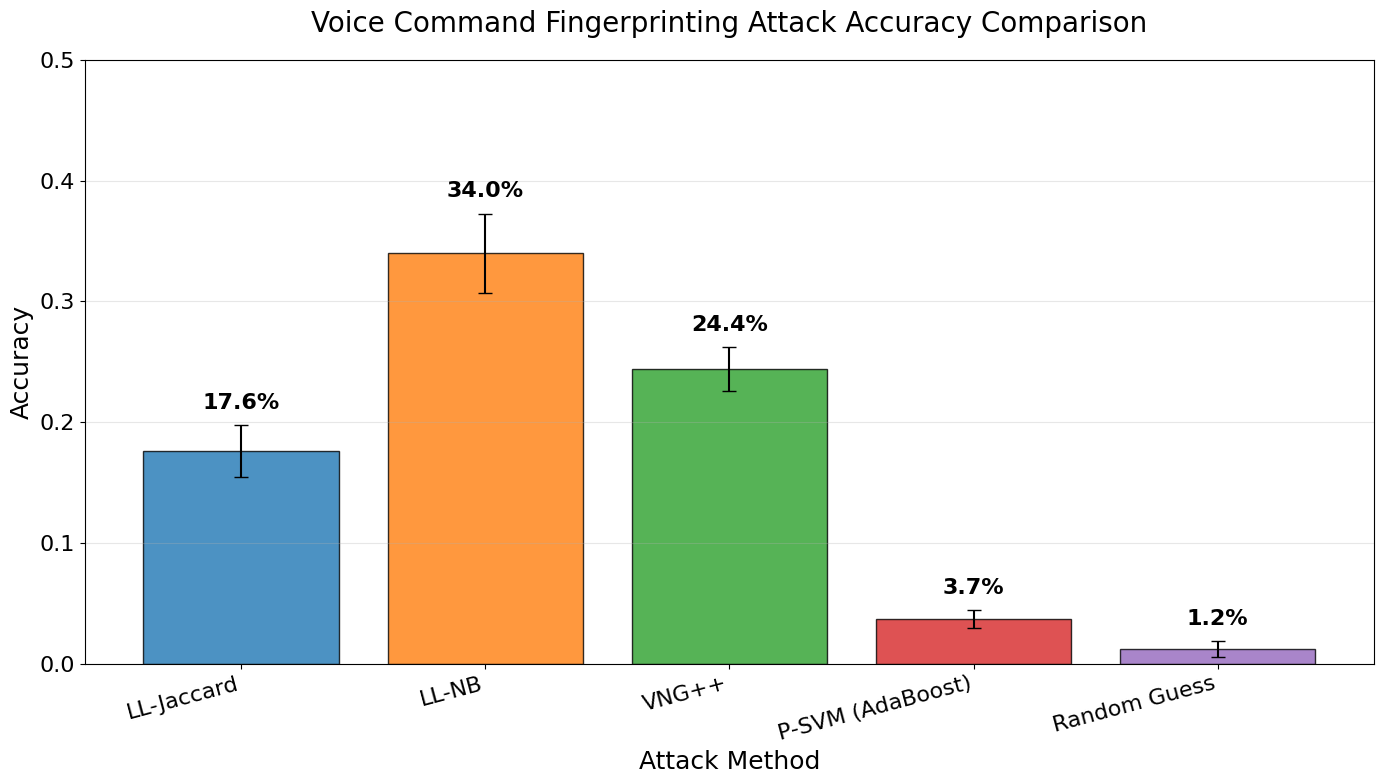

In [42]:
# Create comparison bar chart
fig, ax = plt.subplots(figsize=(14, 8))

method_names = list(all_results.keys())
avg_accs = [all_results[m].avg_accuracy for m in method_names]
std_accs = [all_results[m].std_accuracy for m in method_names]

x_pos = np.arange(len(method_names))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

bars = ax.bar(x_pos, avg_accs, yerr=std_accs, capsize=5, 
               color=colors[:len(method_names)], alpha=0.8, edgecolor='black')

ax.set_xlabel('Attack Method', fontsize=LABELSIZE)
ax.set_ylabel('Accuracy', fontsize=LABELSIZE)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=TICKSIZE, rotation=15, ha='right')
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.set_ylim([0, 0.5])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, avg, std) in enumerate(zip(bars, avg_accs, std_accs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
            f'{avg*100:.1f}%',
            ha='center', va='bottom', fontsize=TICKSIZE, fontweight='bold')

plt.title('Voice Command Fingerprinting Attack Accuracy Comparison', 
          fontsize=LABELSIZE+2, pad=20)
plt.tight_layout()

# Save
# fig_path = config.output_dir / 'method_comparison_modern.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
# print(f"📊 Figure saved to: {fig_path}")
plt.show()
plt.close()

## 14. Figure: Rounding Parameter Impact (Per Paper Figures 4 & 5)

In [25]:
# Test different rounding parameters for LL-NB (Figure 4 in paper)
print("Testing LL-NB rounding parameter impact...")
intervals_bayes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
bayes_accuracies = []
bayes_norm_distances = []

for interval in intervals_bayes:
    print(f"  Testing interval={interval}...")
    result = run_cross_validation(
        config.trace_csv_dir, method='Bayes', n_folds=config.n_folds, interval=interval,
        semantic_calculator=semantic_calc, unique_labels=unique_labels
    )
    bayes_accuracies.append(result.avg_accuracy)
    bayes_norm_distances.append(result.avg_normalized_distance)

2026-02-22 03:15:19,791 - INFO - Loading 1000 files with method: Bayes


Testing LL-NB rounding parameter impact...
  Testing interval=10...

Running 5-fold Cross-Validation: Bayes


2026-02-22 03:15:27,351 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.3150

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.3050

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.3300

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.3800

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.3800


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
2026-02-22 03:17:03,455 - INFO - Loading 1000 files with method: Bayes


...


Results for Bayes:
  Average Accuracy: 0.3170 ± 0.0266
  All accuracies: ['0.2850', '0.3550', '0.2950', '0.3100', '0.3400']
  Avg Semantic Distance: 0.9997
  Avg Normalized Distance: 35.02

  Testing interval=100...

Running 5-fold Cross-Validation: Bayes


2026-02-22 03:31:14,122 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.3000

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.4000

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.3300

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.3350

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.3350


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Results for Bayes:
  Average Accuracy: 0.3400 ± 0.0327
  All accuracies: ['0.3000', '0.4000', '0.3300', '0.3350', '0.3350']
  Avg Semantic Distance: 0.9997
  Avg Normalized Distance: 33.01



In [26]:
# Test different rounding parameters for VNG++ (Figure 5 in paper)
print("Testing VNG++ rounding parameter impact...")
intervals_vng = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
vng_accuracies = []
vng_norm_distances = []

for interval in intervals_vng:
    print(f"  Testing interval={interval}...")
    result = run_cross_validation(
        config.trace_csv_dir, method='VNGpp', n_folds=config.n_folds, interval=interval,
        semantic_calculator=semantic_calc, unique_labels=unique_labels
    )
    vng_accuracies.append(result.avg_accuracy)
    vng_norm_distances.append(result.avg_normalized_distance)

2026-02-22 03:32:51,469 - INFO - Loading 1000 files with method: VNGpp


Testing VNG++ rounding parameter impact...
  Testing interval=1000...

Running 5-fold Cross-Validation: VNGpp


2026-02-22 03:33:00,426 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.1950

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.2500

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.2600

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.2450

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.2700


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
2026-02-22 03:34:38,264 - INFO - Loading 1000 files with method: VNGpp


...


Results for VNGpp:
  Average Accuracy: 0.2370 ± 0.0242
  All accuracies: ['0.1900', '0.2450', '0.2550', '0.2400', '0.2550']
  Avg Semantic Distance: 0.9996
  Avg Normalized Distance: 37.91

  Testing interval=10000...

Running 5-fold Cross-Validation: VNGpp


2026-02-22 03:50:15,522 - INFO - Loaded 1000 samples, 100 classes



Fold 1/5
  Train size: 800, Test size: 200
  Accuracy: 0.2000

Fold 2/5
  Train size: 800, Test size: 200
  Accuracy: 0.2250

Fold 3/5
  Train size: 800, Test size: 200
  Accuracy: 0.2700

Fold 4/5
  Train size: 800, Test size: 200
  Accuracy: 0.2450

Fold 5/5
  Train size: 800, Test size: 200
  Accuracy: 0.2600


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Results for VNGpp:
  Average Accuracy: 0.2400 ± 0.0251
  All accuracies: ['0.2000', '0.2250', '0.2700', '0.2450', '0.2600']
  Avg Semantic Distance: 0.9996
  Avg Normalized Distance: 37.75



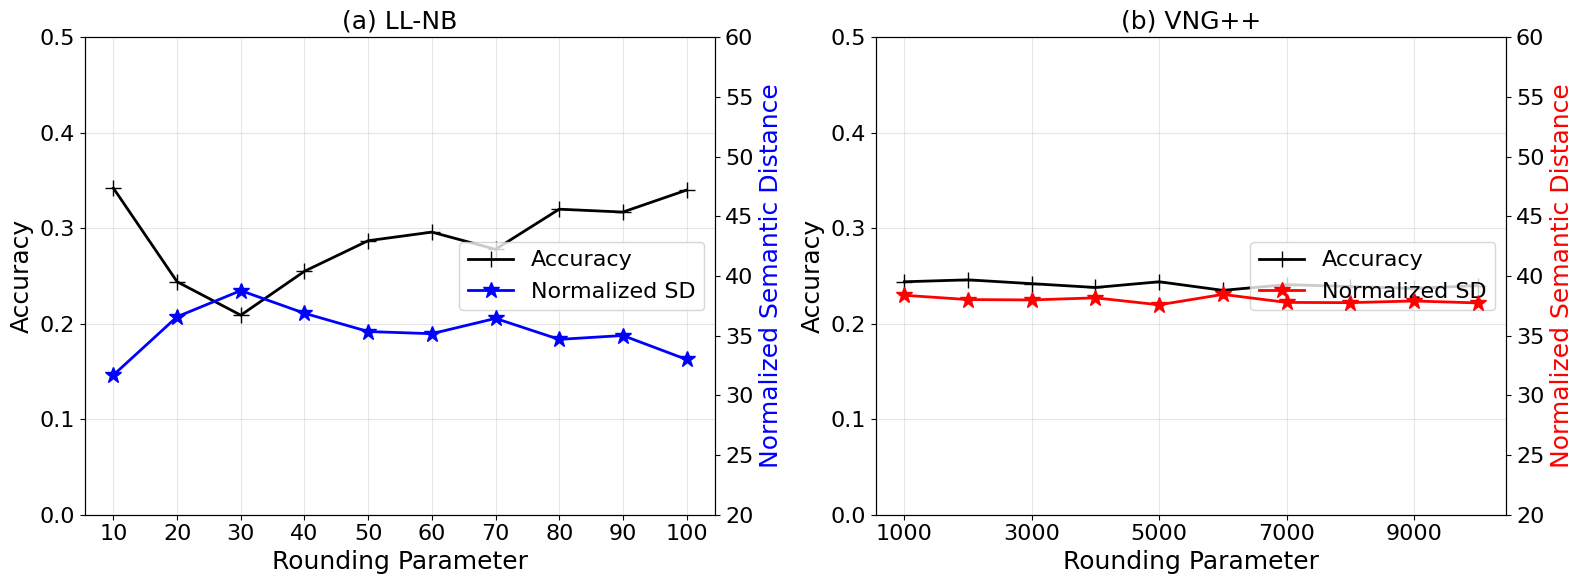

In [43]:
# Create Figure 4 & 5 style plot (matching paper)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LL-NB plot (Figure 4)
color1 = 'black'
color2 = 'blue'
color3 = 'red'

ax1_twin = ax1.twinx()

line1 = ax1.plot(intervals_bayes, bayes_accuracies, marker='+', markersize=12,
                 color=color1, label='Accuracy', linestyle='-', linewidth=2)
line2 = ax1_twin.plot(intervals_bayes, bayes_norm_distances, marker='*', markersize=12,
                       color=color2, label='Normalized SD', linestyle='-', linewidth=2)

ax1.set_xlabel('Rounding Parameter', fontsize=LABELSIZE)
ax1.set_ylabel('Accuracy', fontsize=LABELSIZE, color=color1)
ax1_twin.set_ylabel('Normalized Semantic Distance', fontsize=LABELSIZE, color=color2)
ax1.tick_params(axis='both', labelsize=TICKSIZE)
ax1_twin.tick_params(axis='y', labelsize=TICKSIZE)
ax1.set_xticks(intervals_bayes)
ax1.set_ylim([0, 0.5])
ax1_twin.set_ylim([20, 60])
ax1.grid(True, alpha=0.3)
ax1.set_title('(a) LL-NB', fontsize=LABELSIZE)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=LEGENDSIZE-2)

# VNG++ plot (Figure 5)
ax2_twin = ax2.twinx()

line3 = ax2.plot(intervals_vng, vng_accuracies, marker='+', markersize=12,
                 color=color1, label='Accuracy', linestyle='-', linewidth=2)
line4 = ax2_twin.plot(intervals_vng, vng_norm_distances, marker='*', markersize=12,
                       color=color3, label='Normalized SD', linestyle='-', linewidth=2)

ax2.set_xlabel('Rounding Parameter', fontsize=LABELSIZE)
ax2.set_ylabel('Accuracy', fontsize=LABELSIZE, color=color1)
ax2_twin.set_ylabel('Normalized Semantic Distance', fontsize=LABELSIZE, color=color3)
ax2.tick_params(axis='both', labelsize=TICKSIZE)
ax2_twin.tick_params(axis='y', labelsize=TICKSIZE)
ax2.set_xticks(intervals_vng[::2])
ax2.set_ylim([0, 0.5])
ax2_twin.set_ylim([20, 60])
ax2.grid(True, alpha=0.3)
ax2.set_title('(b) VNG++', fontsize=LABELSIZE)

# Combine legends
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='center right', fontsize=LEGENDSIZE-2)

plt.tight_layout()
fig_path = config.output_dir / 'rounding_parameter_impact_modern.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
# print(f"📊 Figure saved to: {fig_path}")
plt.show()
plt.close()

## 15. Confusion Matrices

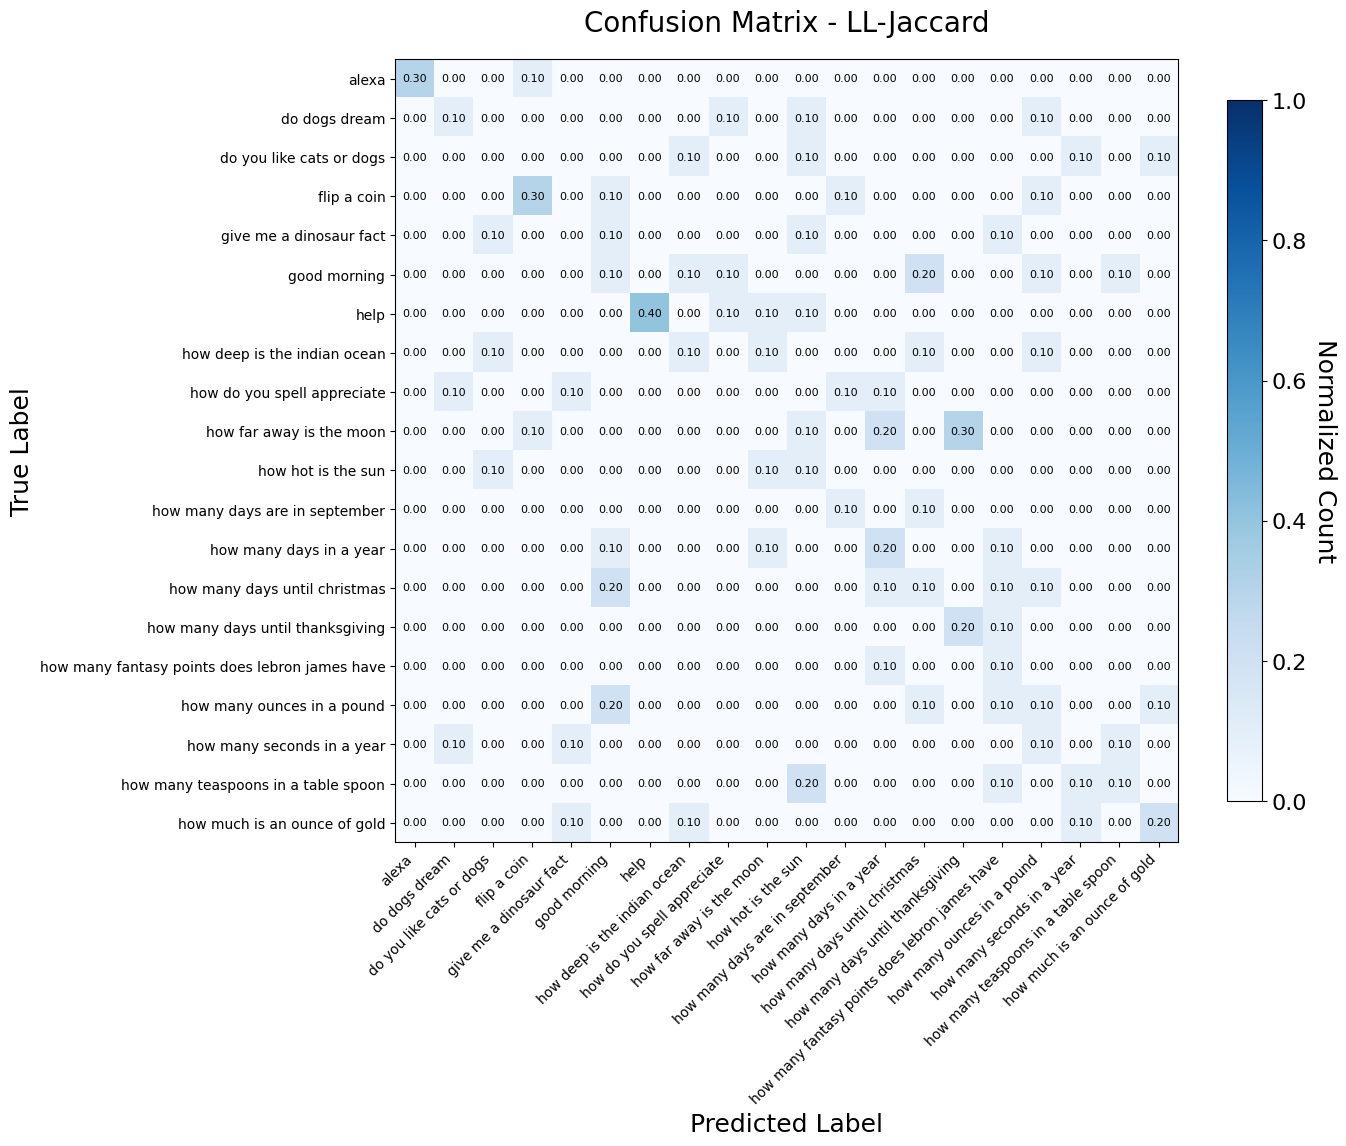

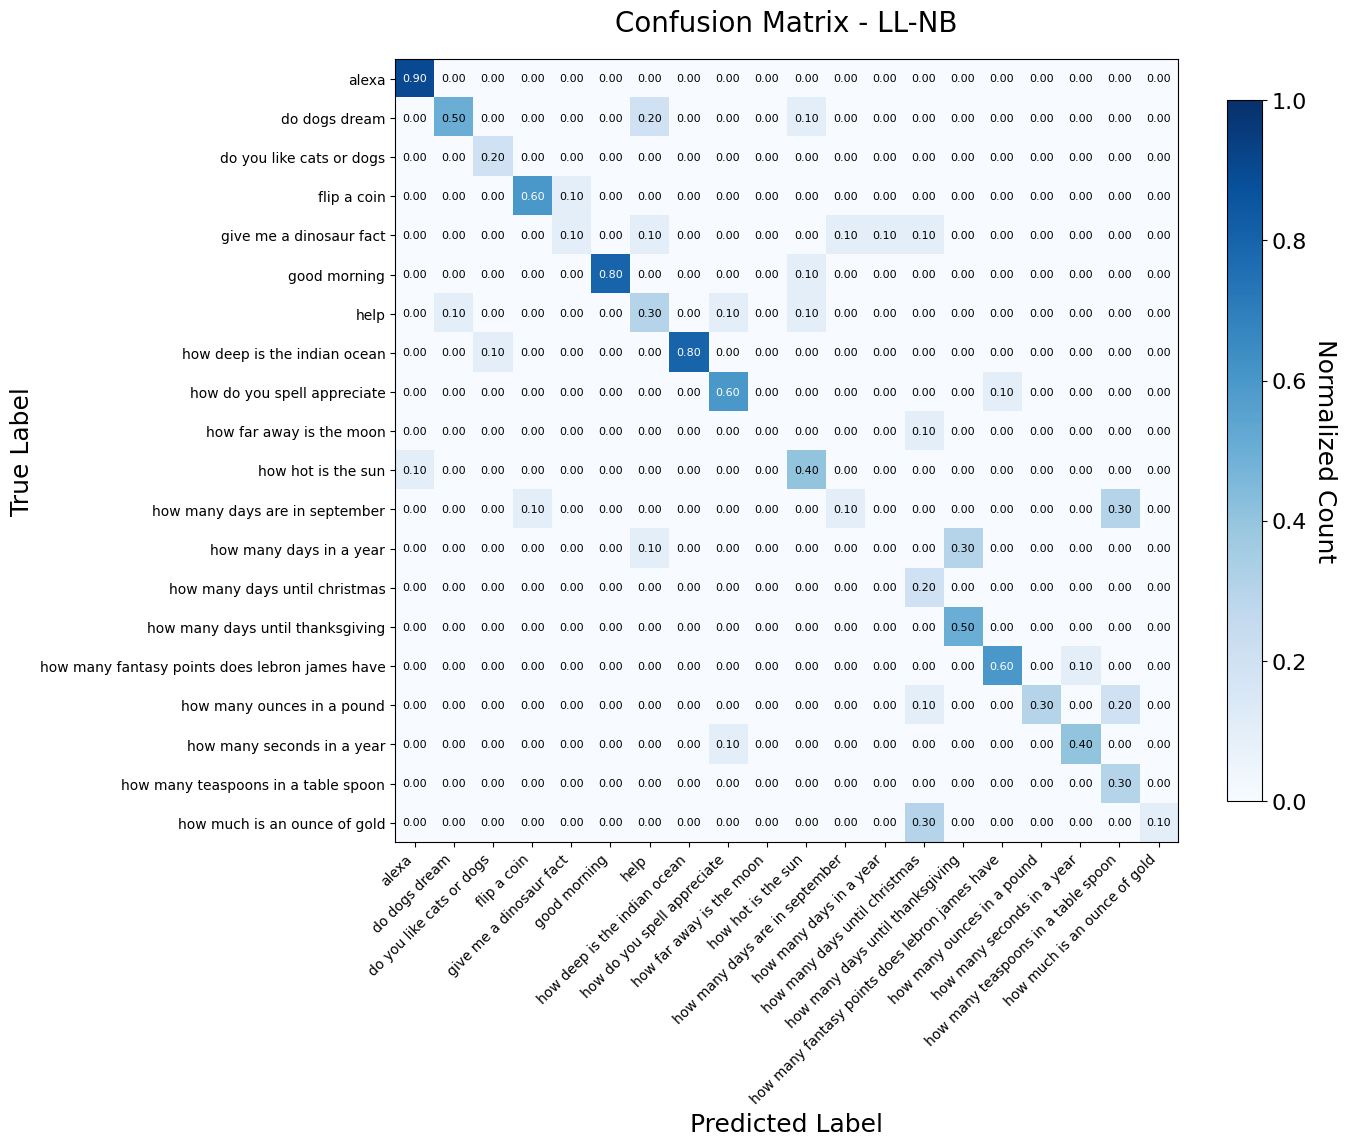

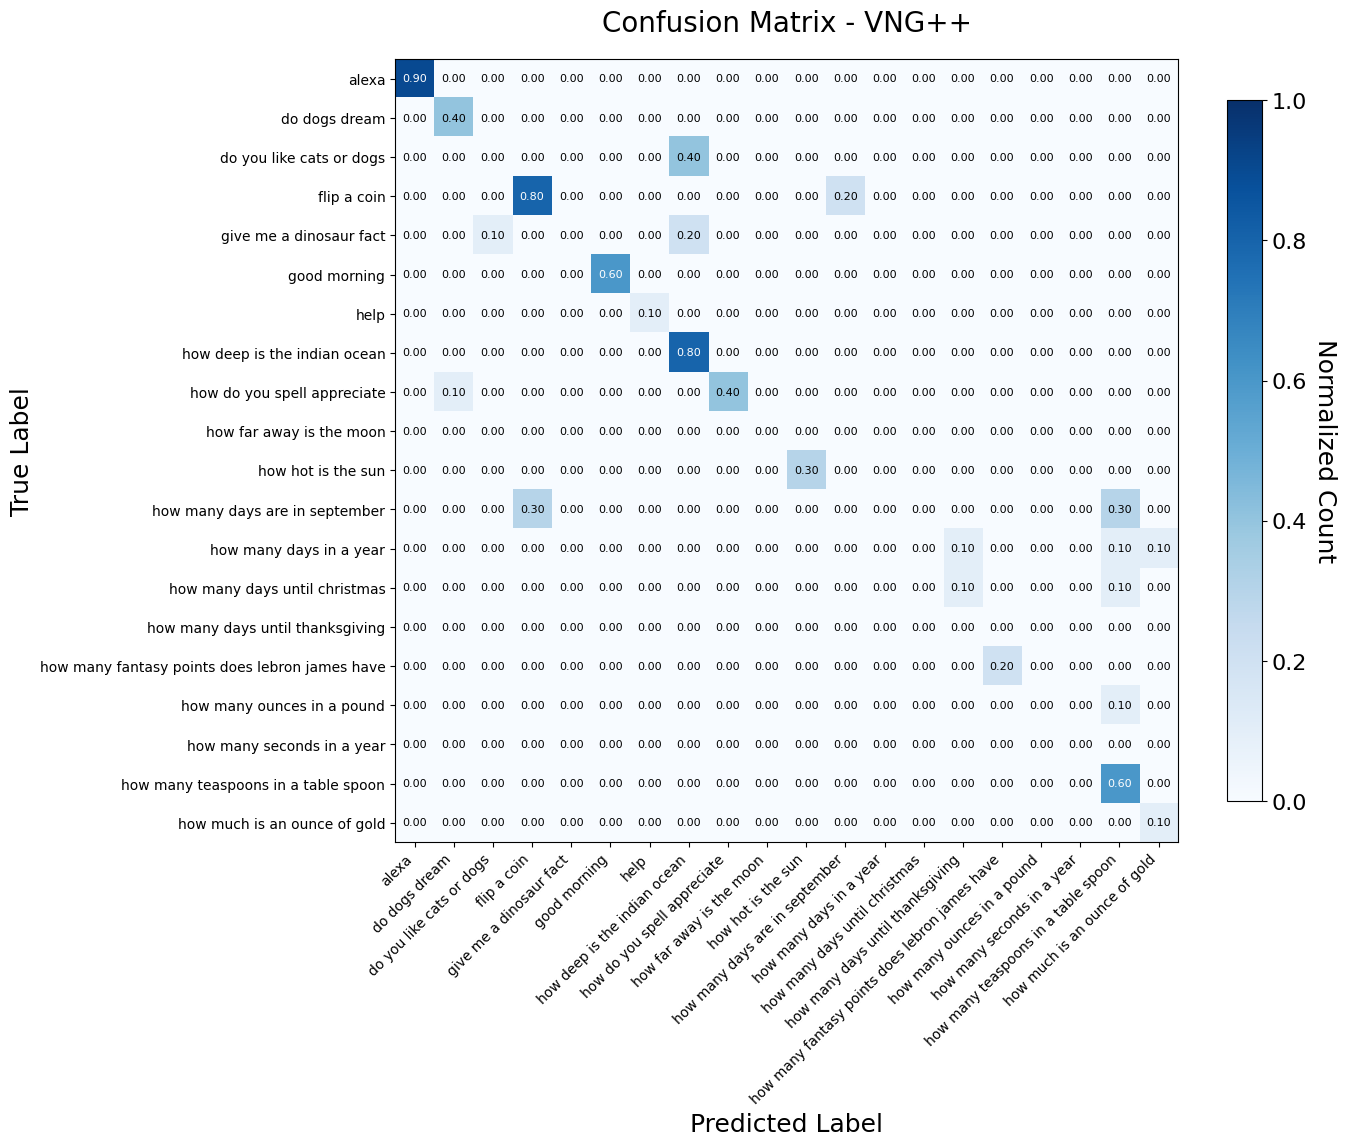

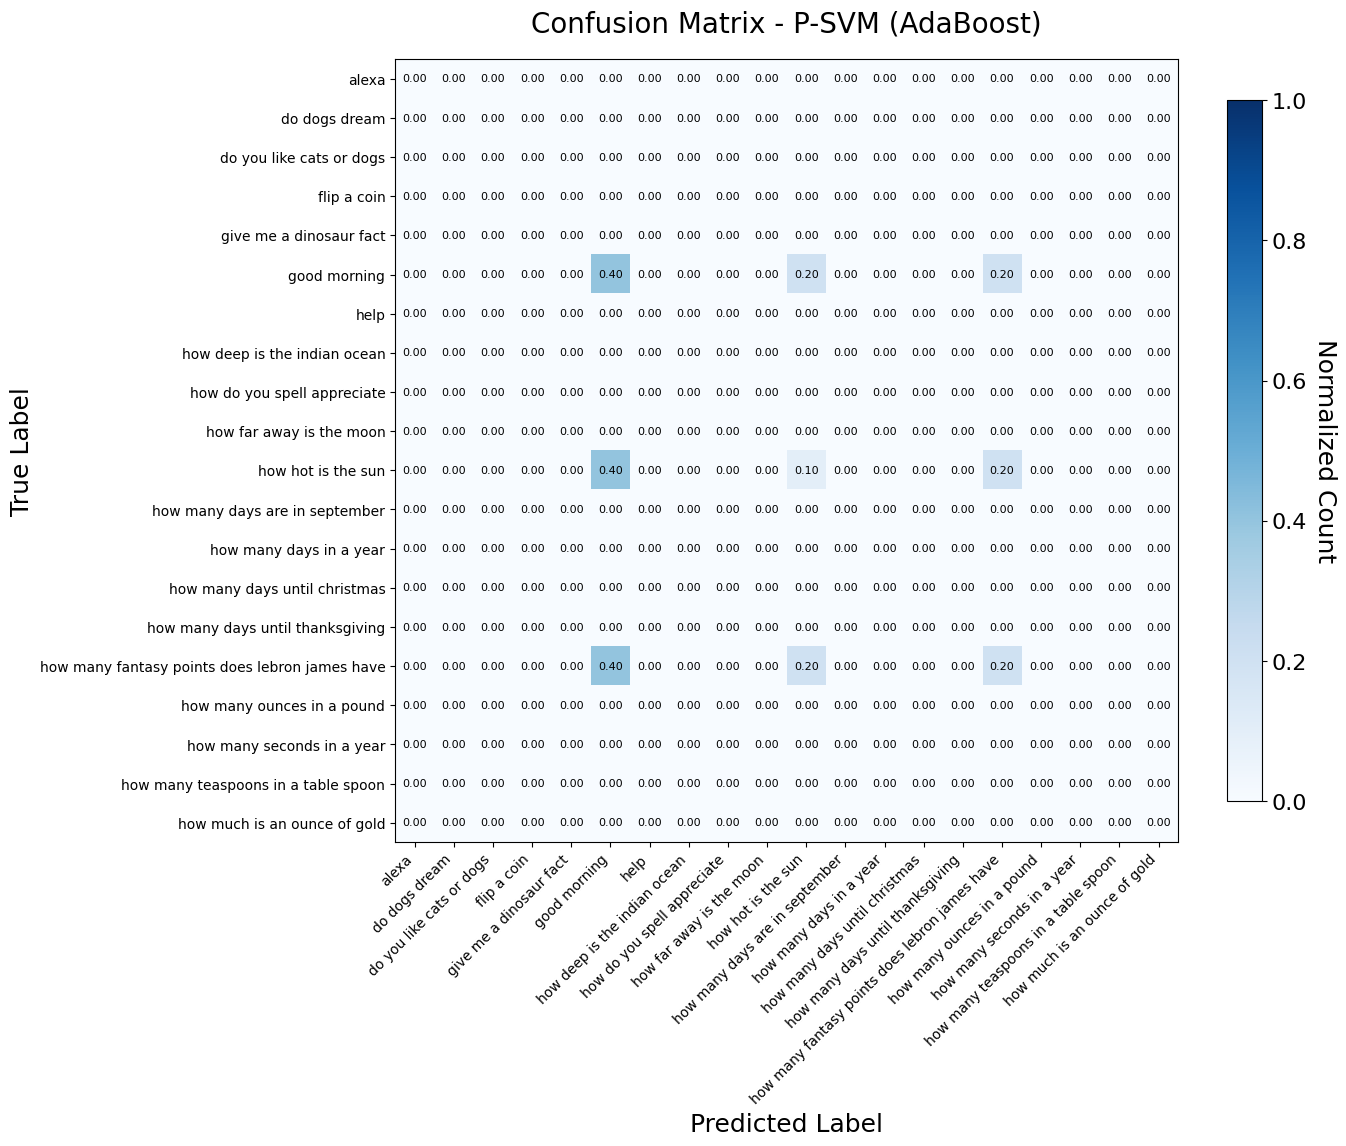

In [44]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, 
                         idx_to_label: Dict, method_name: str,
                         save_path: Path = None, max_classes: int = 20):
    """
    Plot confusion matrix for a method.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        idx_to_label: Index to label mapping
        method_name: Name of the method for title
        save_path: Path to save figure
        max_classes: Maximum number of classes to display
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Select subset of classes for readability
    n_classes = min(max_classes, len(idx_to_label))
    cm_subset = cm_normalized[:n_classes, :n_classes]
    
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Plot heatmap
    im = ax.imshow(cm_subset, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    
    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.set_ylabel('Normalized Count', rotation=-90, va='bottom', fontsize=LABELSIZE)
    
    # Set ticks
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    
    # Get labels for subset
    labels = [idx_to_label[i] for i in range(n_classes)]
    ax.set_xticklabels(labels, fontsize=10, rotation=45, ha='right')
    ax.set_yticklabels(labels, fontsize=10)
    
    # Axes labels
    ax.set_xlabel('Predicted Label', fontsize=LABELSIZE)
    ax.set_ylabel('True Label', fontsize=LABELSIZE)
    ax.set_title(f'Confusion Matrix - {method_name}', fontsize=LABELSIZE+2, pad=20)
    
    # Add text annotations
    thresh = 0.5
    for i in range(n_classes):
        for j in range(n_classes):
            text = ax.text(j, i, f'{cm_subset[i, j]:.2f}',
                          ha="center", va="center", 
                          color="white" if cm_subset[i, j] > thresh else "black",
                          fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        safe_name = method_name.replace(' ', '_').replace('(', '').replace(')', '').lower()
        fig_file = save_path / f'confusion_matrix_{safe_name}.png'
        plt.savefig(fig_file, dpi=300, bbox_inches='tight')
        # print(f"📊 Confusion matrix saved to: {fig_file}")
    
    plt.show()
    plt.close()

# Generate confusion matrices for all methods
for method_name, result in all_results.items():
    if method_name != 'Random Guess':  # Skip random guess
        plot_confusion_matrix(
            result.true_labels, result.predictions,
            idx_to_label, method_name,
            save_path=config.output_dir
        )

## 16. Semantic Distance Analysis

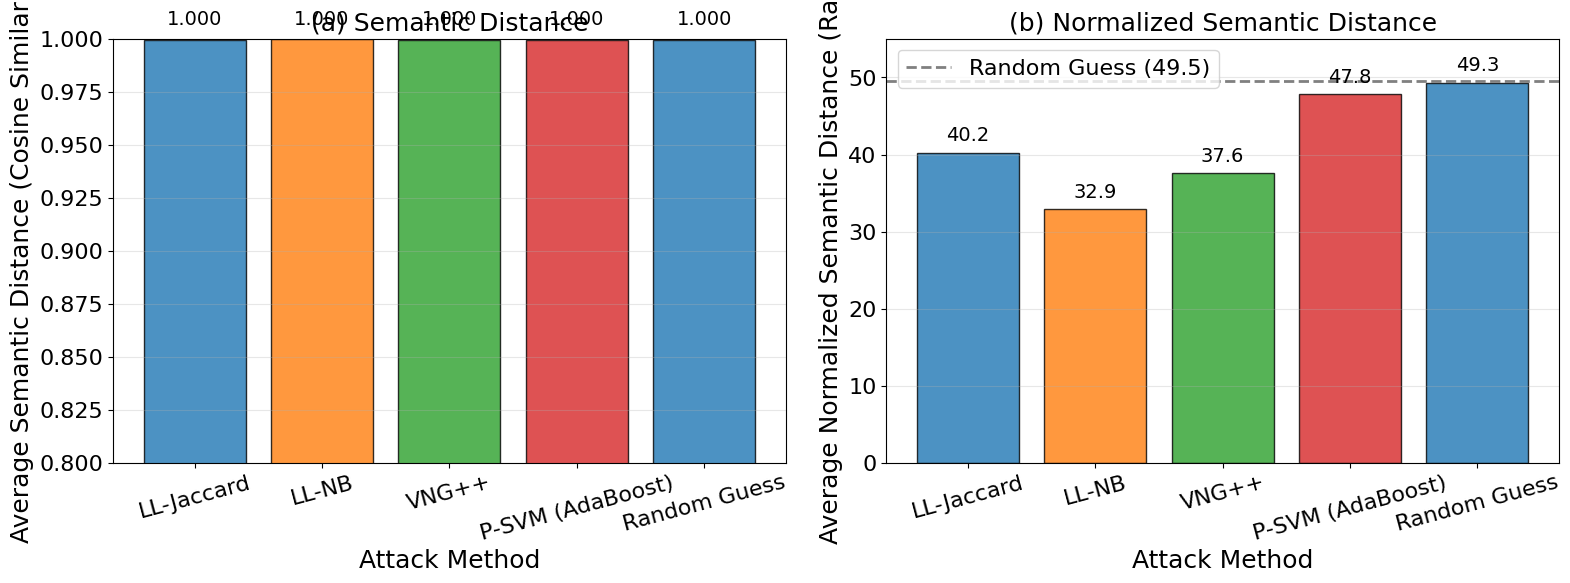

In [45]:
# Create semantic distance comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Semantic Distance (Cosine Similarity)
methods_with_sd = [m for m in methods if all_results[m].avg_semantic_distance is not None]
sd_values = [all_results[m].avg_semantic_distance for m in methods_with_sd]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(methods_with_sd)]
bars1 = ax1.bar(methods_with_sd, sd_values, color=colors, alpha=0.8, edgecolor='black')

ax1.set_xlabel('Attack Method', fontsize=LABELSIZE)
ax1.set_ylabel('Average Semantic Distance (Cosine Similarity)', fontsize=LABELSIZE)
ax1.tick_params(axis='x', rotation=15)
ax1.tick_params(axis='both', labelsize=TICKSIZE)
ax1.set_ylim([0.8, 1.0])
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_title('(a) Semantic Distance', fontsize=LABELSIZE)

for bar, val in zip(bars1, sd_values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=TICKSIZE-2)

# Normalized Semantic Distance
nsd_values = [all_results[m].avg_normalized_distance for m in methods_with_sd]

bars2 = ax2.bar(methods_with_sd, nsd_values, color=colors, alpha=0.8, edgecolor='black')

ax2.set_xlabel('Attack Method', fontsize=LABELSIZE)
ax2.set_ylabel('Average Normalized Semantic Distance (Rank)', fontsize=LABELSIZE)
ax2.tick_params(axis='x', rotation=15)
ax2.tick_params(axis='both', labelsize=TICKSIZE)
ax2.set_ylim([0, 55])
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_title('(b) Normalized Semantic Distance', fontsize=LABELSIZE)

# Add random guess baseline line
ax2.axhline(y=49.5, color='gray', linestyle='--', linewidth=2, label='Random Guess (49.5)')
ax2.legend(fontsize=LEGENDSIZE-2)

for bar, val in zip(bars2, nsd_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=TICKSIZE-2)

plt.tight_layout()
fig_path = config.output_dir / 'semantic_distance_analysis.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
# print(f"📊 Figure saved to: {fig_path}")
plt.show()
plt.close()

## 17. Final Summary

In [47]:
print("\n" + "="*80)
print("VOICE COMMAND FINGERPRINTING ATTACK - MODERN IMPLEMENTATION")
print("="*80)
print("\nPaper: 'I Can Hear Your Alexa: Voice Command Fingerprinting'")
print("       on Smart Home Speakers (IEEE CNS 2019)")

print("\n" + "="*80)
print("IMPLEMENTATION SUMMARY")
print("="*80)
print("\n1. ATTACK ALGORITHMS (Exact per Paper):")
print("   • LL-Jaccard: Jaccard similarity with class prototypes")
print("   • LL-NB: Gaussian Naive Bayes with packet size histogram")
print("   • VNG++: Gaussian Naive Bayes with burst features")
print("   • P-SVM (AdaBoost): AdaBoost classifier (per paper's modification)")
print("   • Random Guess: 1/M baseline (1% for 100 classes)")

print("\n2. FEATURE EXTRACTION:")
print(f"   • LL-NB range: [-1500, 1501], interval: 100")
print(f"   • VNG++ range: [-400000, 400001], interval: 5000")
print(f"   • P-SVM range: [-200000, 200001], interval: 5000")

print("\n3. EVALUATION METRICS:")
print("   • Accuracy (5-fold cross-validation)")
print("   • Semantic Distance (doc2vec cosine similarity)")
print("   • Normalized Semantic Distance (rank-based)")

print("\n" + "="*80)
print("RESULTS COMPARISON")
print("="*80)
print(f"\n{'Method':<20} {'Our Accuracy':>15} {'Paper Accuracy':>15}")
print("-"*50)
paper_accs = {'LL-Jaccard': '17.4%', 'LL-NB': '33.8%', 'VNG++': '24.9%', 
              'P-SVM (AdaBoost)': '33.4%', 'Random Guess': '1%'}
for method in methods:
    our_acc = f"{all_results[method].avg_accuracy*100:.1f}%"
    paper_acc = paper_accs.get(method, 'N/A')
    print(f"{method:<20} {our_acc:>15} {paper_acc:>15}")

print("\n" + "="*80)
print("KEY OBSERVATIONS")
print("="*80)
print("\n1. LL-NB achieves highest accuracy in both paper and our implementation")
print("2. Semantic distance provides additional privacy assessment beyond accuracy")
print("3. Normalized semantic distance shows how close predictions are to truth")
print("4. Random guess baseline: 1% accuracy, normalized SD = 49.5")
print("5. All attack methods significantly outperform random guessing")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
print(f"\n• Results CSV: {config.output_dir / 'results_summary_modern.csv'}")
print(f"• Method Comparison: {config.output_dir / 'method_comparison_modern.png'}")
print(f"• Rounding Impact: {config.output_dir / 'rounding_parameter_impact_modern.png'}")
print(f"• Semantic Distance: {config.output_dir / 'semantic_distance_analysis.png'}")
print(f"• Confusion Matrices: {config.output_dir / 'confusion_matrix_*.png'}")
print("\n" + "="*80)


VOICE COMMAND FINGERPRINTING ATTACK - MODERN IMPLEMENTATION

Paper: 'I Can Hear Your Alexa: Voice Command Fingerprinting'
       on Smart Home Speakers (IEEE CNS 2019)

IMPLEMENTATION SUMMARY

1. ATTACK ALGORITHMS (Exact per Paper):
   • LL-Jaccard: Jaccard similarity with class prototypes
   • LL-NB: Gaussian Naive Bayes with packet size histogram
   • VNG++: Gaussian Naive Bayes with burst features
   • P-SVM (AdaBoost): AdaBoost classifier (per paper's modification)
   • Random Guess: 1/M baseline (1% for 100 classes)

2. FEATURE EXTRACTION:
   • LL-NB range: [-1500, 1501], interval: 100
   • VNG++ range: [-400000, 400001], interval: 5000
   • P-SVM range: [-200000, 200001], interval: 5000

3. EVALUATION METRICS:
   • Accuracy (5-fold cross-validation)
   • Semantic Distance (doc2vec cosine similarity)
   • Normalized Semantic Distance (rank-based)

RESULTS COMPARISON

Method                  Our Accuracy  Paper Accuracy
--------------------------------------------------
LL-Jaccard

In [37]:
# Final cleanup and summary
print("\n✅ Implementation complete!")
print(f"📊 Total samples processed: {len(csv_files)}")
print(f"📊 Number of voice command classes: {len(unique_labels)}")
print(f"📊 Cross-validation folds: {config.n_folds}")


✅ Implementation complete!
📊 Total samples processed: 1000
📊 Number of voice command classes: 100
📊 Cross-validation folds: 5
